# Request Characteristics EDA

This notebook explores response time by request characteristics, GPU usage, and workflow latency.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Inspection

In [17]:
df = pd.read_csv("../cleanup/Olena_Log_Template_Proposed.csv")
df.head()

,chat_id,test_id,scenario_name,scenario_purpose,how_to_start,input_type,model,image_input,text_input,model_output,...,error_message,cpu_per_second_pct,cpu_avg_pct,gpu_per_second_pct,gpu_avg_pct,memory_per_second_mb,memory_avg_mb,throughput_per_minute,throughput_per_second,notes
0,1475432104,1,Text Input - Model A,Test response and processing time for text-onl...,Trigger n8n via Telegram bot with plain text i...,Text Only,minicpm-o-2_6,...,/promptText Analyze the tone of this product r...,The tone in this statement can be classified a...,...,NaN,"[67,67,67,67,67]",67.00,"[0,4,4,5,5]",3.60,"[6947,7012,7019,7022,7034]",7007.0,12.03,0.2004,NaN
1,1475432104,2,Text Input - Model B,Same as #1 but using Model B to compare perfor...,Trigger n8n via Telegram bot with plain text i...,Text Only,gemma-3-12b-it,...,/promptText Analyze the tone of this product r...,The tone of this review is **Neutral**.\n\nHer...,...,NaN,"[67,67,67,67,67,67,67,67,67,67,67,67,68,68,68,...",67.29,"[5,2,1,2,2,3,3,3,3,3,3,2,2,2,2,3,2]",2.53,"[7052,7134,7124,7124,7117,7117,7125,7129,7119,...",7104.0,3.40,0.0566,NaN
2,1475432104,3,Text Input - Model C,Same as #1 but using Model C,Trigger n8n via Telegram bot with plain text i...,Text Only,pixtral-12b,...,/promptText Analyze the tone of this product r...,The tone of this product review can be classif...,...,NaN,"[68,68,68,68,68,68,68,68]",68.00,"[2,3,3,2,2,2,2,2]",2.25,"[7097,7152,7167,7156,7134,7142,7142,7137]",7141.0,7.10,0.1183,NaN
3,1475432104,4,Text Input - Model D,Same as #1 but using Model D,Trigger n8n via Telegram bot with plain text i...,Text Only,qwen2-vl-7b-instruct,...,/promptText Analyze the tone of this product r...,The tone of this product review can be classif...,...,NaN,"[68,68,68,68,68]",68.00,"[3,4,4,5,5]",4.20,"[7138,7194,7197,7203,7197]",7186.0,12.54,0.2091,NaN
4,1475432104,5,Text+Image Input - Model A,Test text + image input handling by Model A,Upload text+image via Telegram bot or webhook ...,Text + Image,minicpm-o-2_6,/9j/4AAQSkZJRgABAQEASABIAAD/2wBDAAQDAwQDAwQEAw...,/generateImageText Describe the scene in detai...,The image depicts an outdoor setting where sev...,...,NaN,"[68,68,68,68,68,68,68,68,69,69]",68.20,"[0,62,3,4,5,5,5,5,5,5]",9.90,"[7206,7285,7288,7293,7289,7291,7306,7298,7298,...",7285.0,5.75,0.0958,NaN


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   chat_id                     600 non-null    int64  
 1   test_id                     600 non-null    int64  
 2   scenario_name               600 non-null    str    
 3   scenario_purpose            600 non-null    str    
 4   how_to_start                600 non-null    str    
 5   input_type                  600 non-null    str    
 6   model                       600 non-null    str    
 7   image_input                 584 non-null    str    
 8   text_input                  584 non-null    str    
 9   model_output                472 non-null    str    
 10  workflow_name               600 non-null    str    
 11  workflow_start_time         460 non-null    str    
 12  workflow_end_time           460 non-null    str    
 13  workflow_time_hhmmss        460 non-null    st

In [ ]:
df.shape

(600, 30)

In [ ]:
df.columns.tolist()

['chat_id',
 'test_id',
 'scenario_name',
 'scenario_purpose',
 'how_to_start',
 'input_type',
 'model',
 'image_input',
 'text_input',
 'model_output',
 'workflow_name',
 'workflow_start_time',
 'workflow_end_time',
 'workflow_time_hhmmss',
 'workflow_time_seconds',
 'model_start_time',
 'model_end_time',
 'model_response_time_hhmmss',
 'model_time_seconds',
 'success',
 'error_message',
 'cpu_per_second_pct',
 'cpu_avg_pct',
 'gpu_per_second_pct',
 'gpu_avg_pct',
 'memory_per_second_mb',
 'memory_avg_mb',
 'throughput_per_minute',
 'throughput_per_second',
 'notes']

# Response Time by Request Characteristics

The analysis below examines successful model runs and compares model response time across different request/input types.

In [12]:
# Keep only successful model runs.
# Failed or not-executed requests do not have valid response-time measurements,
# so they should not be included in the response-time analysis

df_success = df[df["success"] == "Yes"].copy()

# Check the size of the filtered dataset.
df_success.shape

(460, 30)

In [13]:
# Count the number of successful requests in each input type.
# This gives the frequency distribution for the categorical variable input_type.

df_success["input_type"].value_counts()

input_type
Mixed           312
Text Only       116
Text + Image     16
Image Only       16
Name: count, dtype: int64

In [14]:
# Calculate the relative frequency (percentage) of each input type.
# normalize=True converts counts into proportions, and multiplying by 100
# converts them into percentages.

(df_success["input_type"].value_counts(normalize=True) * 100).round(1)

input_type
Mixed           67.8
Text Only       25.2
Text + Image     3.5
Image Only       3.5
Name: proportion, dtype: float64

In [15]:
# Calculate descriptive statistics for model response time
# grouped by request/input type.
# The table includes count, mean, standard deviation, minimum,
# quartiles, median, and maximum.

df_success.groupby("input_type")["model_time_seconds"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
input_type,,,,,,,,
Image Only,16.0,32.38,25.91,5.0,11.5,28.5,50.0,99.0
Mixed,312.0,34.20,38.48,2.0,11.0,22.0,37.0,200.0
Text + Image,16.0,47.94,59.45,10.0,16.0,28.5,55.0,246.0
Text Only,116.0,39.64,45.36,2.0,12.0,22.0,50.5,211.0


### Initial observations

The dataset is unbalanced across request types. Mixed requests represent the largest
group (67.8% of successful runs), while Text + Image and Image Only requests each
represent only 3.5%.

Text + Image requests have the highest mean response time (47.94 seconds), followed
by Text Only (39.64 seconds), Mixed (34.20 seconds), and Image Only (32.38 seconds).

For all request types, the mean response time is higher than the median. The relatively
large standard deviations and high maximum values suggest that the response-time
distributions may be right-skewed and contain unusually long response times.
Because some request-type groups have small sample sizes, these comparisons should
be interpreted cautiously.

## Distribution of Response Time by Input Type

A boxplot is used to compare the distribution, median, spread, and potential outliers
of model response time across request types.

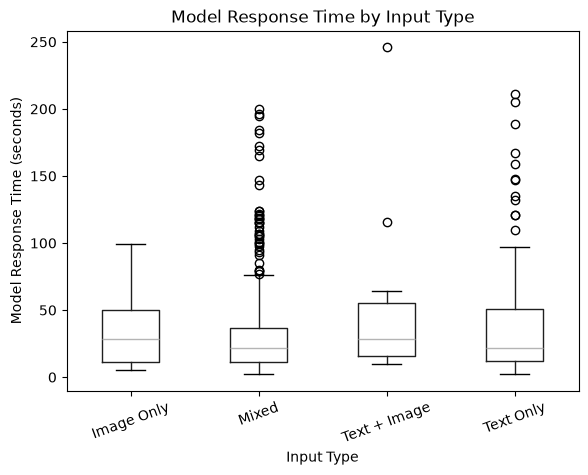

In [19]:
# Compare the distribution of model response time across input types.
# The boxplot shows the median, quartiles, overall spread, and potential outliers.

df_success.boxplot(
    column="model_time_seconds",
    by="input_type",
    grid=False
)

plt.title("Model Response Time by Input Type")
plt.suptitle("")
plt.xlabel("Input Type")
plt.ylabel("Model Response Time (seconds)")
plt.xticks(rotation=20)

plt.show()

Boxplot observations

The boxplot shows substantial variability in response time across all request types.
Mixed and Text Only requests contain several unusually long response times, while
Text + Image includes one particularly extreme observation near 246 seconds.

The upper outliers and the fact that mean response times are higher than the medians
suggest positively skewed response-time distributions. However, the request-type
groups are very different in size, particularly for Text + Image and Image Only,
so comparisons should be interpreted cautiously.

## Frequency of Successful Requests by Input Type

The bar chart below shows the number of successful model runs for each request/input type.

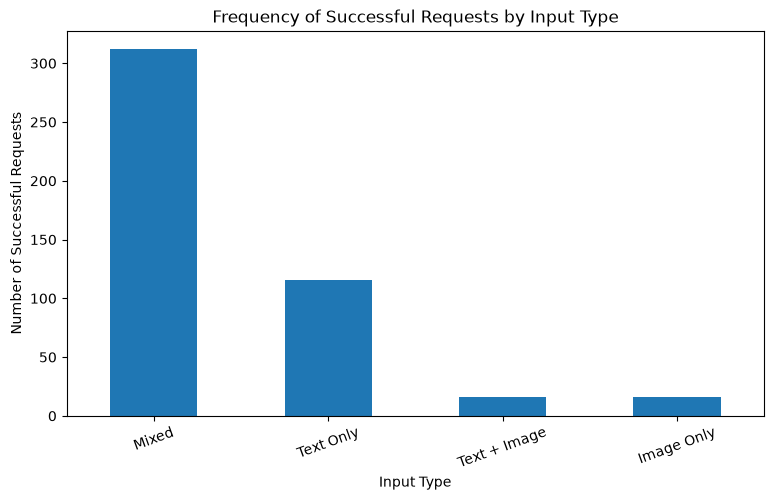

In [22]:
# Count successful requests in each input type.
input_type_counts = df_success["input_type"].value_counts()

# Create a bar chart of the frequency distribution.
input_type_counts.plot(
    kind="bar",
    figsize=(9, 5)
)

# Add labels and title.
plt.title("Frequency of Successful Requests by Input Type")
plt.xlabel("Input Type")
plt.ylabel("Number of Successful Requests")

# Rotate category labels slightly for readability.
plt.xticks(rotation=20)

plt.show()

### Frequency observations

The bar chart confirms that the successful runs are heavily concentrated in the Mixed and Text Only categories. Because the group sizes are highly unequal, response-time comparisons across input types should be interpreted cautiously.